# Force Validation Analysis
Combines loadcell, gui, camera streams → 100 Hz (nearest-neighbour) → steady-state extraction → combined CSV

In [1]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── session to analyse ────────────────────────────────────────────────────────
SESSION_DIR  = "/home/sujith/Documents/NOARK_backbone/csv_data/trial3"
OUTPUT_NAME  = "pos_1_trial_3"
OUTPUT_DIR   = "/home/sujith/Documents/NOARK_backbone/csv_data/trial3"

# ── analysis parameters ───────────────────────────────────────────────────────
RESAMPLE_HZ     = 100
RESAMPLE_PERIOD = f"{1000//RESAMPLE_HZ}ms"
NN_TOLERANCE    = pd.Timedelta("10ms")

HOLD_TIME_S     = 2.0          # sweep step hold duration (must match firmware)
FORCE_THRESHOLD = 1.0          # N — direction error masked below this
SKIP_ZERO_N     = True         # skip steps where target magnitude == 0

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1 — Load raw CSVs

In [2]:
def load_ts(path, **kwargs):
    df = pd.read_csv(path, **kwargs)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp").sort_index()
    return df

df_lc      = load_ts(os.path.join(SESSION_DIR, "loadcell.csv"))
df_gui     = load_ts(os.path.join(SESSION_DIR, "gui.csv"))
df_cam     = load_ts(os.path.join(SESSION_DIR, "camera.csv"))
df_sweep   = load_ts(os.path.join(SESSION_DIR, "sweep_targets.csv"))

print(f"loadcell   : {len(df_lc):6d} rows  ({len(df_lc)/(df_lc.index[-1]-df_lc.index[0]).total_seconds():.1f} Hz)")
print(f"gui        : {len(df_gui):6d} rows  ({len(df_gui)/(df_gui.index[-1]-df_gui.index[0]).total_seconds():.1f} Hz)")
print(f"sweep steps: {len(df_sweep):6d}")
print(f"camera     : {len(df_cam):6d} rows")

loadcell   :  21231 rows  (188.6 Hz)
gui        :  15087 rows  (134.0 Hz)
sweep steps:     28
camera     :      1 rows


## 2 — Resample to 100 Hz (nearest-neighbour, no interpolation)

In [12]:
# Common 100 Hz grid covering the full session
t_start = min(df_lc.index[0], df_gui.index[0])
t_end   = max(df_lc.index[-1], df_gui.index[-1])
idx_100 = pd.date_range(t_start, t_end, freq=RESAMPLE_PERIOD)

def nearest_resample(df, idx, tol):
    """For each tick in idx pick the actual nearest sample within tol."""
    return df.reindex(idx, method="nearest", tolerance=tol)

lc_100  = nearest_resample(df_lc,  idx_100, NN_TOLERANCE)
gui_100 = nearest_resample(df_gui, idx_100, NN_TOLERANCE)

# Camera is a single reference position — broadcast to all rows
pos_x = df_cam["pos_x"].iloc[0]
pos_z = df_cam["pos_z"].iloc[0]

print(f"100 Hz grid: {len(idx_100)} ticks  ({(t_end-t_start).total_seconds():.1f} s)")
print(f"lc  valid  : {lc_100.notna().all(axis=1).sum()} / {len(idx_100)}")
print(f"gui valid  : {gui_100.notna().all(axis=1).sum()} / {len(idx_100)}")

100 Hz grid: 11261 ticks  (112.6 s)
lc  valid  : 10487 / 11261
gui valid  : 11234 / 11261


## 3 — Compute quantities at 100 Hz

In [13]:
# ── Measured (load cell) ──────────────────────────────────────────────────────
Fml = np.hypot(lc_100["Fx"], lc_100["Fy"])          # measured magnitude (N)
Fdl = np.degrees(np.arctan2(lc_100["Fy"], lc_100["Fx"]))  # measured direction (°)

# ── Commanded (gui) ───────────────────────────────────────────────────────────
Fmg = gui_100["magnitude"]   # commanded magnitude (N)
Fdg = gui_100["direction"]   # commanded direction (°)

print("Quantities computed.")

Quantities computed.


In [5]:
# # ── Diagnostic: why are steps failing? ───────────────────────────────────────
# print("=== Time range check ===")
# print(f"sweep_targets : {df_sweep.index[0]}  →  {df_sweep.index[-1]}")
# print(f"loadcell      : {df_lc.index[0]}  →  {df_lc.index[-1]}")
# print(f"gui           : {df_gui.index[0]}  →  {df_gui.index[-1]}")
# print(f"Fml range     : {Fml.min():.3f} N  →  {Fml.max():.3f} N")
# print(f"Fmg range     : {Fmg.min():.3f} N  →  {Fmg.max():.3f} N")
# print()

# print("=== First 3 steps: what Fml looks like inside each window ===")
# for i, (ts, row) in enumerate(steps.head(3).iterrows()):
#     step_end = steps.index[i+1] if i+1 < len(steps) else ts + pd.Timedelta(seconds=HOLD_TIME_S)
#     window = Fml.loc[ts:step_end].dropna()
#     lo = row["target_mag_N"] * (1 - SETTLE_TOL)
#     hi = row["target_mag_N"] * (1 + SETTLE_TOL)
#     print(f"Step {int(row['step'])}  target={row['target_mag_N']}N  band=[{lo:.2f}, {hi:.2f}]")
#     print(f"  window size={len(window)}  Fml min={window.min():.3f}  max={window.max():.3f}  mean={window.mean():.3f}")
#     print(f"  samples in band: {((window>=lo)&(window<=hi)).sum()}  (need {SETTLE_N})")
#     print()


## 4 — Extract mid-window steady-state per sweep step

In [6]:
# Only non-zero target steps
steps = df_sweep[df_sweep["target_mag_N"] > 0].copy() if SKIP_ZERO_N else df_sweep.copy()
steps = steps[steps["feasible"] == 1]

step_records = []
for i, (ts, row) in enumerate(steps.iterrows()):
    step_end = steps.index[i + 1] if i + 1 < len(steps) else ts + pd.Timedelta(seconds=HOLD_TIME_S)
    step_records.append({
        "step"         : int(row["step"]),
        "step_start"   : ts,
        "step_end"     : step_end,
        "target_mag"   : row["target_mag_N"],
        "target_angle" : row["target_angle_deg"],
        "valid"        : True,
    })

df_steps = pd.DataFrame(step_records)
print(f"{len(df_steps)}/28 steps included (full window, transient included)")
df_steps[["step", "target_mag", "target_angle", "step_start", "step_end"]]

28/28 steps included (full window, transient included)


,step,target_mag,target_angle,step_start,step_end
0,0,5.0,-129.474,2026-06-15 15:17:39.789255,2026-06-15 15:17:41.889705
1,1,10.0,-129.474,2026-06-15 15:17:41.889705,2026-06-15 15:17:43.927508
2,2,15.0,-129.474,2026-06-15 15:17:43.927508,2026-06-15 15:17:45.908250
3,3,24.0,-129.474,2026-06-15 15:17:45.908250,2026-06-15 15:17:47.895690
4,4,5.0,-116.438,2026-06-15 15:17:47.895690,2026-06-15 15:17:49.886923
5,5,10.0,-116.438,2026-06-15 15:17:49.886923,2026-06-15 15:17:51.906802
6,6,15.0,-116.438,2026-06-15 15:17:51.906802,2026-06-15 15:17:53.893852
7,7,24.0,-116.438,2026-06-15 15:17:53.893852,2026-06-15 15:17:55.890275
8,8,5.0,-103.402,2026-06-15 15:17:55.890275,2026-06-15 15:17:57.897812
9,9,10.0,-103.402,2026-06-15 15:17:57.897812,2026-06-15 15:17:59.891168


## 5 — Build combined DataFrame (steady-state windows only)

In [7]:
chunks = []
for _, sr in df_steps.iterrows():
    mask = (idx_100 >= sr["step_start"]) & (idx_100 < sr["step_end"])
    ticks = idx_100[mask]
    if len(ticks) == 0:
        continue

    chunk = pd.DataFrame(index=ticks)
    chunk["t_rel"]        = (ticks - sr["step_start"]).total_seconds()
    chunk["step"]         = int(sr["step"])
    chunk["target_mag"]   = sr["target_mag"]
    chunk["target_angle"] = sr["target_angle"]
    chunk["Fmg"]          = Fmg.reindex(ticks)   # commanded magnitude
    chunk["Fml"]          = Fml.reindex(ticks)   # measured magnitude
    chunk["Fdg"]          = Fdg.reindex(ticks)   # commanded direction
    chunk["Fdl"]          = Fdl.reindex(ticks)   # measured direction
    chunks.append(chunk)

df_combined = pd.concat(chunks).rename_axis("timestamp")
print(f"Combined: {len(df_combined)} rows across {len(chunks)} steps")
df_combined.head()

Combined: 5611 rows across 28 steps


,t_rel,step,target_mag,target_angle,Fmg,Fml,Fdg,Fdl
timestamp,,,,,,,,
2026-06-15 15:17:39.798246,0.008991,0,5.0,-129.474,5.0,0.437604,-129.474278,37.105574
2026-06-15 15:17:39.808246,0.018991,0,5.0,-129.474,5.0,0.031048,-129.474278,165.068583
2026-06-15 15:17:39.818246,0.028991,0,5.0,-129.474,5.0,NaN,-129.474278,NaN
2026-06-15 15:17:39.828246,0.038991,0,5.0,-129.474,5.0,NaN,-129.474278,NaN
2026-06-15 15:17:39.838246,0.048991,0,5.0,-129.474,5.0,0.679577,-129.474278,-145.491477


## 6 — Save combined CSV

In [8]:
out_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_NAME}.csv")
df_combined.to_csv(out_path)
print(f"Saved → {out_path}")

Saved → /home/sujith/Documents/NOARK_backbone/csv_data/trial3/pos_1_trial_3.csv


## 7 — Quick plots

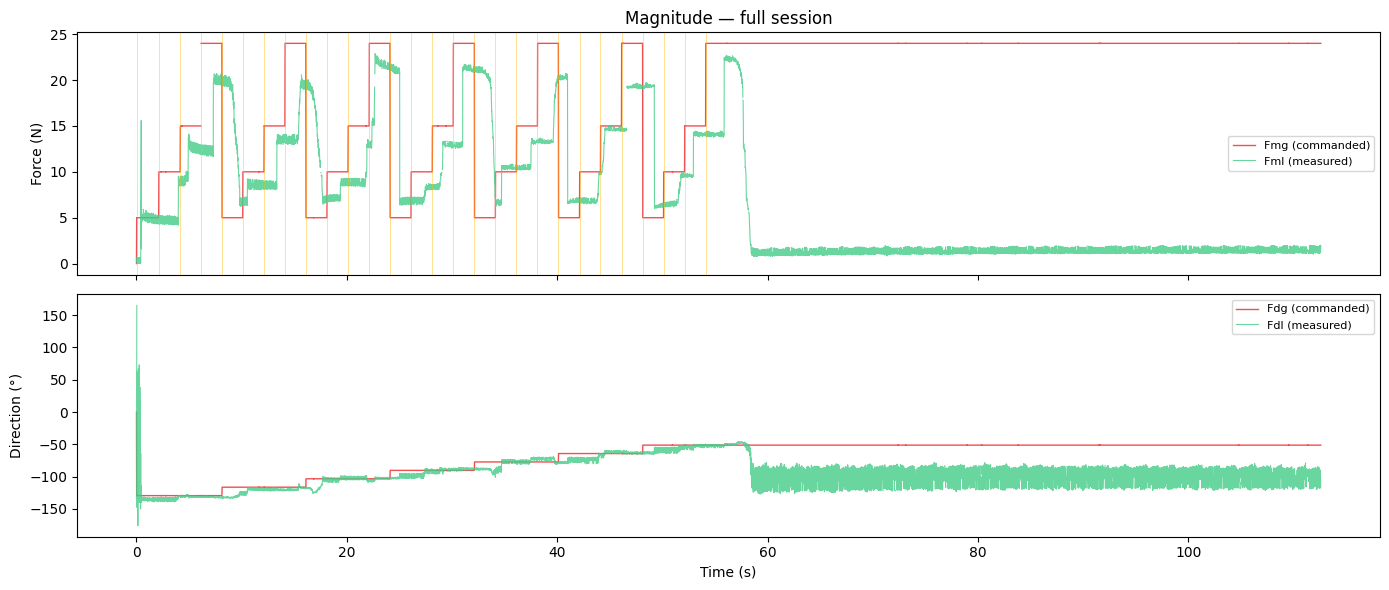

In [9]:
# ── Full session overview ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

t_sec = (idx_100 - idx_100[0]).total_seconds()

axes[0].plot(t_sec, Fmg.values, label="Fmg (commanded)", color="#f05050", lw=1)
axes[0].plot(t_sec, Fml.values, label="Fml (measured)",  color="#44cc88", lw=0.8, alpha=0.8)
for _, sr in df_steps.iterrows():
    t_rel = (sr["step_start"] - idx_100[0]).total_seconds()
    axes[0].axvline(t_rel, color="#ffbb00", lw=0.6, alpha=0.5)
axes[0].set_ylabel("Force (N)"); axes[0].legend(fontsize=8); axes[0].set_title("Magnitude — full session")

axes[1].plot(t_sec, Fdg.values, label="Fdg (commanded)", color="#f05050", lw=1)
axes[1].plot(t_sec, Fdl.values, label="Fdl (measured)",  color="#44cc88", lw=0.8, alpha=0.8)
axes[1].set_ylabel("Direction (°)"); axes[1].set_xlabel("Time (s)")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

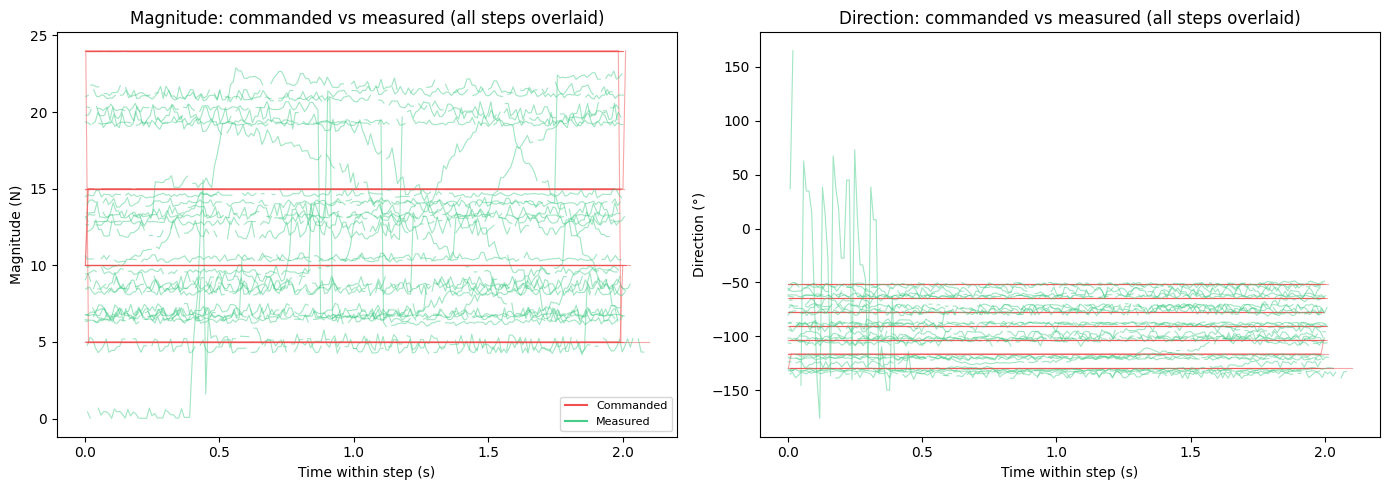

In [10]:
# ── Commanded vs Measured per step ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for step_num, grp in df_combined.groupby("step"):
    axes[0].plot(grp["t_rel"], grp["Fmg"], color="#f05050", lw=0.8, alpha=0.5)
    axes[0].plot(grp["t_rel"], grp["Fml"], color="#44cc88", lw=0.8, alpha=0.5)
    axes[1].plot(grp["t_rel"], grp["Fdg"], color="#f05050", lw=0.8, alpha=0.5)
    axes[1].plot(grp["t_rel"], grp["Fdl"], color="#44cc88", lw=0.8, alpha=0.5)

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], color="#f05050", label="Commanded"),
          Line2D([0],[0], color="#44cc88", label="Measured")]
axes[0].legend(handles=legend, fontsize=8)
axes[0].set_xlabel("Time within step (s)"); axes[0].set_ylabel("Magnitude (N)")
axes[0].set_title("Magnitude: commanded vs measured (all steps overlaid)")
axes[1].set_xlabel("Time within step (s)"); axes[1].set_ylabel("Direction (°)")
axes[1].set_title("Direction: commanded vs measured (all steps overlaid)")

plt.tight_layout(); plt.show()

In [11]:
df_combined

,t_rel,step,target_mag,target_angle,Fmg,Fml,Fdg,Fdl
timestamp,,,,,,,,
2026-06-15 15:17:39.798246,0.008991,0,5.0,-129.474,5.0,0.437604,-129.474278,37.105574
2026-06-15 15:17:39.808246,0.018991,0,5.0,-129.474,5.0,0.031048,-129.474278,165.068583
2026-06-15 15:17:39.818246,0.028991,0,5.0,-129.474,5.0,NaN,-129.474278,NaN
2026-06-15 15:17:39.828246,0.038991,0,5.0,-129.474,5.0,NaN,-129.474278,NaN
2026-06-15 15:17:39.838246,0.048991,0,5.0,-129.474,5.0,0.679577,-129.474278,-145.491477
...,...,...,...,...,...,...,...,...
2026-06-15 15:18:35.858246,1.957414,27,24.0,-51.258,24.0,22.339441,-51.257898,-49.948138
2026-06-15 15:18:35.868246,1.967414,27,24.0,-51.258,24.0,22.674907,-51.257898,-50.509871
2026-06-15 15:18:35.878246,1.977414,27,24.0,-51.258,24.0,22.144376,-51.257898,-51.245637
